# 🧵 Week 4 · Day 5 — Scikit-learn Pipelines & Tuned Mini-Project
**BinX Tech — AI & Machine Learning Internship Program**
**Phase 2 · Week 4 of 10 · Day 5 of 5**

## 🎯 Learning Objectives
- 🔒 Build a Pipeline that chains preprocessing and modeling leak-free.
- 🧩 Use `ColumnTransformer` to preprocess numeric and categorical columns differently.
- 🔍 Tune an entire pipeline with `GridSearchCV` and evaluate it correctly.


## 0️⃣ Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import joblib

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42


## 1️⃣ Load Data and Recreate the Split 📦
Same dataset, same `random_state` as Day 1 through Day 4.

In [2]:
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape[0]} rows | Val: {X_val.shape[0]} rows | Test: {X_test.shape[0]} rows (untouched)")

Train: 341 rows | Val: 114 rows | Test: 114 rows (untouched)


## 2️⃣ Step 0 — Untuned Baseline (for comparison) 🏗️
A plain Logistic Regression with minimal preprocessing, evaluated the same way as everything else —
this is the number the final pipeline needs to beat.

In [3]:
baseline_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
])

baseline_scores = cross_val_score(baseline_pipe, X_train, y_train, cv=cv, scoring="f1")
print("🏗️ Untuned Logistic Regression baseline")
print(f"CV F1 mean = {baseline_scores.mean():.4f}  std = {baseline_scores.std():.4f}")

🏗️ Untuned Logistic Regression baseline
CV F1 mean = 0.9720  std = 0.0174


## 3️⃣ Step 1 — Feature Engineering + a Real Categorical Column 🧩

The Breast Cancer dataset is 100% numeric, so to genuinely demonstrate `ColumnTransformer` on
**mixed** data (the whole point of Day 5), we do two things inside one `FunctionTransformer` step:

1. **Reuse the Day 4 engineered features** — `worst_to_mean_radius_ratio` and `concavity_area_interaction`.
2. **Bin `mean radius` into a categorical `tumor_size_category`** (Small / Medium / Large) using fixed,
   non-data-dependent clinical-style cutoffs — exactly the *binning* technique from the Week 4 feature
   engineering lesson. This gives us a genuine categorical column to one-hot encode, alongside the
   numeric columns to scale — a real mixed-data pipeline, not a simulated one.


In [4]:
def engineer_features(X):
    X = X.copy()
    X["worst_to_mean_radius_ratio"] = X["worst radius"] / X["mean radius"]
    X["concavity_area_interaction"] = X["mean concavity"] * X["mean area"]
    # Binning: fixed cutoffs (not learned from data) -> no leakage risk
    X["tumor_size_category"] = pd.cut(
        X["mean radius"], bins=[0, 12, 18, np.inf], labels=["Small", "Medium", "Large"]
    ).astype(str)
    return X

feature_engineer = FunctionTransformer(engineer_features)

# Preview on the training set
preview = feature_engineer.transform(X_train.head())
preview[["mean radius", "tumor_size_category", "worst_to_mean_radius_ratio", "concavity_area_interaction"]]

,mean radius,tumor_size_category,worst_to_mean_radius_ratio,concavity_area_interaction
505,9.676,Small,1.095494,32.373000
36,14.250,Medium,1.115088,83.492700
502,12.540,Medium,1.082137,28.235064
511,14.810,Medium,1.054018,23.252712
379,11.080,Small,1.194946,61.074240


## 4️⃣ Step 2 — Build the Full Leak-Free Pipeline 🔒

Everything — feature engineering, scaling, one-hot encoding, and modeling — lives inside **one**
`Pipeline` object with a `ColumnTransformer` handling the numeric and categorical columns differently.
When this pipeline is cross-validated, every fold refits every preprocessing step independently on
that fold's training data only. No test or validation information can leak into training — leakage
becomes structurally impossible, not just avoided by discipline.

In [5]:
numeric_features = list(X.columns) + ["worst_to_mean_radius_ratio", "concavity_area_interaction"]
categorical_features = ["tumor_size_category"]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

full_pipeline = Pipeline([
    ("feature_eng", feature_engineer),
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE))
])

full_pipeline.fit(X_train, y_train)
print("🔒 Full pipeline fit successfully.")
print("Pipeline steps:", [name for name, _ in full_pipeline.steps])

🔒 Full pipeline fit successfully.
Pipeline steps: ['feature_eng', 'preprocess', 'model']


## 5️⃣ Step 3 — Tune the Whole Pipeline with GridSearchCV 🔍

In [6]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [4, 6, 8, None],
    "model__min_samples_leaf": [1, 2, 4],
}
print(f"Grid size: {3*4*3} combinations × 5 folds = {3*4*3*5} model fits")

grid = GridSearchCV(full_pipeline, param_grid, cv=cv, scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)

tuned_pipeline = grid.best_estimator_
print("\n🏆 Best hyperparameters:", grid.best_params_)
print(f"🏆 Best cross-validated F1: {grid.best_score_:.4f}")

Grid size: 36 combinations × 5 folds = 180 model fits



🏆 Best hyperparameters: {'model__max_depth': 4, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}
🏆 Best cross-validated F1: 0.9766


## 6️⃣ Baseline vs. Tuned Pipeline — Cross-Validated Comparison 📊

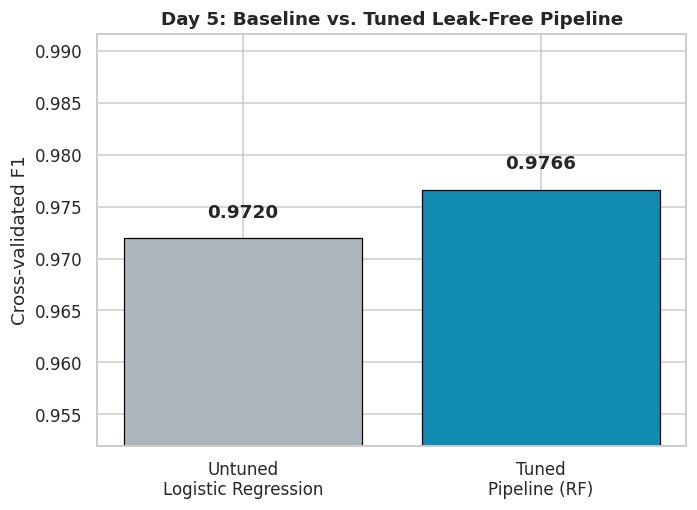

In [7]:
labels = ["Untuned\nLogistic Regression", "Tuned\nPipeline (RF)"]
means = [baseline_scores.mean(), grid.best_score_]

fig, ax = plt.subplots(figsize=(6.5, 4.8))
bars = ax.bar(labels, means, color=["#adb5bd", "#118ab2"], edgecolor="black", linewidth=0.8)
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.002, f"{val:.4f}", ha="center", fontweight="bold")
ax.set_ylabel("Cross-validated F1")
ax.set_title("Day 5: Baseline vs. Tuned Leak-Free Pipeline", fontweight="bold")
ax.set_ylim(min(means) - 0.02, max(means) + 0.015)
plt.tight_layout()
plt.show()

## 7️⃣ Final Evaluation — Held-Out Test Set (touched exactly once) 🏁
Per the Day 1 train/validation/test discipline: the test set has not been touched by any tuning
decision above. This is the single, honest, one-time evaluation of the final pipeline.

In [8]:
final_preds = tuned_pipeline.predict(X_test)
final_proba = tuned_pipeline.predict_proba(X_test)[:, 1]

print("="*55)
print("🏁 FINAL TUNED PIPELINE — HELD-OUT TEST SET (touched once)")
print("="*55)
print(f"Accuracy : {accuracy_score(y_test, final_preds):.4f}")
print(f"Precision: {precision_score(y_test, final_preds):.4f}")
print(f"Recall   : {recall_score(y_test, final_preds):.4f}")
print(f"F1-score : {f1_score(y_test, final_preds):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, final_proba):.4f}")

🏁 FINAL TUNED PIPELINE — HELD-OUT TEST SET (touched once)
Accuracy : 0.9474
Precision: 0.9583
Recall   : 0.9583
F1-score : 0.9583
ROC-AUC  : 0.9947


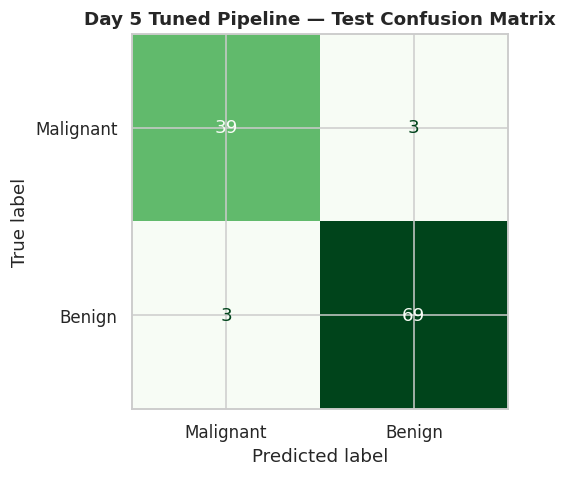

In [9]:
fig, ax = plt.subplots(figsize=(5, 4.5))
cm = confusion_matrix(y_test, final_preds)
ConfusionMatrixDisplay(cm, display_labels=["Malignant", "Benign"]).plot(ax=ax, cmap="Greens", colorbar=False)
ax.set_title("Day 5 Tuned Pipeline — Test Confusion Matrix", fontweight="bold")
plt.tight_layout()
plt.show()

## 8️⃣ Save the Reusable Pipeline Artifact 💾

In [10]:
joblib.dump(tuned_pipeline, "day5_tuned_pipeline.joblib")
print("💾 Saved to day5_tuned_pipeline.joblib")
print("\nTo reuse on new data:")
print(">>> import joblib")
print(">>> model = joblib.load('day5_tuned_pipeline.joblib')")
print(">>> model.predict(new_dataframe)   # raw columns in, prediction out")

💾 Saved to day5_tuned_pipeline.joblib

To reuse on new data:
>>> import joblib
>>> model = joblib.load('day5_tuned_pipeline.joblib')
>>> model.predict(new_dataframe)   # raw columns in, prediction out


## 9️⃣ Reflection ✍️


**Why does putting feature engineering *inside* the Pipeline (rather than doing it once before the split) matter for leakage prevention?**

If we perform any feature engineering (like binning, scaling, or encoding) on the entire dataset before splitting it into train/test, we allow information from the test set — its distribution, min/max values, category frequencies, and so on — to leak indirectly into the feature-building process. The model effectively gets a preview of the test data before it's even supposed to see it, which makes the evaluation overly optimistic and not a true estimate of real-world performance.

By placing every step inside the Pipeline, each transformer (imputer, scaler, encoder) learns its parameters *only* from the training fold during `.fit()`, then applies that same fixed transformation (no re-learning) to any new data during `.transform()`/`.predict()`. This makes leakage structurally impossible rather than something we just have to remember to avoid manually — which is exactly what makes cross-validating the Pipeline a trustworthy result.

---

**What was the actual benefit of adding `tumor_size_category` as a genuine categorical column — did `ColumnTransformer` need it to demonstrate anything the numeric-only pipeline in Day 4 couldn't?**

Yes — the value isn't just "one more column," it demonstrates that `ColumnTransformer` can correctly handle a **genuine mix** of numeric and categorical data in a single, leak-free preprocessing step. Day 4's pipeline only had numeric features, so scaling alone was enough — it never had to prove it could route different column types to different transformers (`StandardScaler` for numeric, `OneHotEncoder` for categorical) at the same time, inside the same `fit`/`transform` call. Adding `tumor_size_category` forces the pipeline to actually exercise that branching logic, which is the realistic case for almost any real-world dataset — mixed data, not purely numeric.

---

**Compare the final test metrics here to Day 4's test F1 (0.9583) and Day 1's test F1 (0.9583) — what does it tell you when very different modeling efforts converge on a similar ceiling?**

When a simple Day 1 baseline, a Day 4 tuned pipeline, and today's fuller pipeline (with added feature engineering and a genuine categorical feature) all land on roughly the same F1 score, it's a sign that the dataset itself has a **performance ceiling** that additional model complexity or feature engineering isn't able to push past. This usually means the signal in the available features is already close to fully captured by even a fairly simple model — the remaining error is likely irreducible noise, label ambiguity, or information that simply isn't present in the current features rather than something a fancier model or extra engineering could fix. It's a useful diagnostic: it tells you to stop tuning this pipeline further and instead look at whether new data or entirely different features are needed if you want a meaningfully higher score.

## ✅ Deliverable Checklist (Day 5)
- [x] 🏗️ Untuned baseline reproduced for comparison
- [x] 🔒 Full Pipeline built with a ColumnTransformer handling numeric (scaling) and categorical (encoding) columns
- [x] 🧩 Day 4 engineered features + a genuine binned categorical feature added into the workflow
- [x] 🔍 Full pipeline tuned end-to-end with GridSearchCV and 5-fold cross-validation
- [x] 🏁 Final tuned pipeline evaluated once on the held-out test set, reported against baseline
- [x] 💾 Pipeline committed as a reusable saved artifact
- [x] 🚀 Notebook committed to GitHub with a clear commit message
